# V1 — ssm-phylo: full pipeline in ONE Colab VM

Runs the whole V1 flow sequentially: **setup → simulate small data → train → evaluate**. Colab gives every notebook a fresh VM, so the environment (deps, Drive mount, repo clone, env vars) does NOT persist between notebooks — this master notebook keeps everything in one session.

**Every cell is idempotent**: re-running (or resuming after a session death) never duplicates work and never errors on already-completed steps. Set `COLAB_DRIVE_SKIP=1` to run headless without Drive (used by CI/nbconvert; local tmp dirs under `/tmp/ssm_v1_colab`).

### Table of contents
1. [Section 1 — Setup](#section-1--setup)
2. [Section 2 — Simulate small data](#section-2--simulate-small-data)
3. [Section 3 — Train](#section-3--train)
4. [Section 4 — Evaluate](#section-4--evaluate)


---
## Section 1 — Setup
GPU detection, Drive mount (skippable), repo bootstrap, dependency install, opt-in weight download, and a model smoke. All env vars are set in ONE cell and read from `os.environ` everywhere else — nothing is hardcoded downstream.


In [83]:
!git -C /content/ssm-phylo pull --ff-only

Already up to date.


In [81]:
!apt-get install -y iqtree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
iqtree is already the newest version (2.0.7+dfsg-1).
0 upgraded, 0 newly installed, 0 to remove and 173 not upgraded.


In [9]:
# --- Generate the BIG dataset from the notebook ---
import os, subprocess, glob

# 1) CRITICAL: remove the old 156-row smoke parquets first.
#    make_splits SKIPS a split if its parquet already exists on Drive,
#    so the big grid would otherwise simulate 100k pairs and then write nothing.
old = glob.glob(os.path.join(os.environ["DATA_DIR"], "*.parquet"))
for p in old:
    os.remove(p)
print("removed old parquets:", old)

# 2) Install iqtree (AliSim) so simulation is fast.
#    Without it, engine="auto" falls back to the pure-Python sampler —
#    fine for 200 alignments, brutally slow for 100k+.
subprocess.run("apt-get update -qq && apt-get install -y -qq iqtree", shell=True, check=False)

# 3) VALIDATE on a small grid first (~3,200 pairs, minutes) — do NOT skip this:
proc = subprocess.Popen(
    ["bash", "scripts/simulate_big.sh",
     "--tip-counts", "10,20,40,80",
     "--trees-per-bin", "200",
     "--lengths", "150,300",
     "--replicates", "2",
     "--workers", "4"],
    env=os.environ, cwd=REPO_DIR, text=True,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
for line in proc.stdout:
    print(line, end="")
print("small-grid exit:", proc.wait())

# 4) Confirm the new train.parquet is much bigger than 156 rows:
import pyarrow.parquet as pq
print("train rows:", pq.read_table(os.path.join(os.environ["DATA_DIR"], "train.parquet")).num_rows)

removed old parquets: []

[simulate_big] command: python -m ssm_phylo.data.simulation big --workers 4 --tip-counts 10,20,40,80 --trees-per-bin 200 --lengths 150,300 --replicates 2
[big] grid: 4 tip counts x 2 lengths x 2 replicates x 200 trees = 3200 (tree, alignment) pairs
[big] trees bin 1/16: tips=10
[simulation] t010_l150_r00_000000 (0/200)
[simulation] t010_l150_r00_000100 (100/200)
[simulation] trees: 200/200 present in /content/data/raw
[big] trees bin 2/16: tips=10
[simulation] t010_l150_r01_000000 (0/200)
[simulation] t010_l150_r01_000100 (100/200)
[simulation] trees: 200/200 present in /content/data/raw
[big] trees bin 3/16: tips=10
[simulation] t010_l300_r00_000000 (0/200)
[simulation] t010_l300_r00_000100 (100/200)
[simulation] trees: 200/200 present in /content/data/raw
[big] trees bin 4/16: tips=10
[simulation] t010_l300_r01_000000 (0/200)
[simulation] t010_l300_r01_000100 (100/200)
[simulation] trees: 200/200 present in /content/data/raw
[big] trees bin 5/16: tips=20
[si

In [11]:
proc = subprocess.Popen(
    ["bash", "scripts/simulate_big.sh", "--background", "--workers", "4"],
    env=os.environ, cwd=REPO_DIR, text=True,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
print(proc.communicate()[0])
print("launched; watch: tail -f /content/data/simulate.log")


[simulate_big] command: python -m ssm_phylo.data.simulation big --workers 4

[simulate_big] started in background (pid 5333); log: /content/data/simulate.log

[simulate_big] tail -f /content/data/simulate.log   |   kill $(cat /content/data/simulate.pid) to stop

launched; watch: tail -f /content/data/simulate.log


In [24]:
import os, glob
for p in glob.glob(os.path.join(os.environ["DATA_DIR"], "*.parquet")):
    os.remove(p)
print("deleted:", glob.glob(os.path.join(os.environ["DATA_DIR"], "*.parquet")))

deleted: []


In [79]:
import os, subprocess

# 1) Is the job still running?
print(subprocess.run(["ps", "aux"], capture_output=True, text=True).stdout[-2500:])

# 2) What engine is it using? (CRITICAL)
log = "/content/data/simulate.log"
if os.path.exists(log):
    txt = open(log).read()
    print("...last 2000 chars of log:\n", txt[-2000:])
    print("\npython-engine lines:", txt.count("python engine"))
    print("alisim lines:", txt.count("alisim"))

# 3) How much has it done?
raw = "/content/data/raw"
n_fasta = len([f for f in os.listdir(raw) if f.endswith(".fasta")]) if os.path.isdir(raw) else 0
print("alignments simulated so far:", n_fasta, "/ ~100800")

ances:10,opendir_timeout_ms:120000,virtual_folders_omit_spaces:true,read_only_mode:false --metadata_server_auth_uri=172.28.0.1:8009/computeMetadata/v1 --preferences=trusted_root_certs_file_path:/opt/google/drive/roots.pem,feature_flag_restart_seconds:129600,mount_point_path:/content/drive --auto_restart_count=1 --first_auto_restart_timestamp=1064
root        3341  0.0  0.0   3632  2084 ?        S    Aug06   0:00 grep --color=auto --line-buffered -E Drive File Stream encountered a problem and has stopped|The domain policy has disabled Drive File Stream
root        3461  0.0  0.0   4364  3032 ?        S    Aug06   0:00 bash -c tail -n +0 -F "/root/.config/Google/DriveFS/Logs/drive_fs.txt" | python3 /opt/google/drive/drive-filter.py > "/root/.config/Google/DriveFS/Logs/timeouts.txt" 
root        3462  0.0  0.0 1229320 4540 ?        Sl   Aug06   0:00 /opt/google/drive/directoryprefetcher_binary -mountpoint=/content/drive
root        3467  0.0  0.0   2824  1736 ?        S    Aug06   0:01 ta

In [80]:
import os, subprocess
pidfile = "/content/data/simulate.pid"
if os.path.exists(pidfile):
    pid = int(open(pidfile).read().strip())
    subprocess.run(["kill", str(pid)], check=False)
    print("killed", pid)

killed 5333


In [77]:
import os, glob
p = glob.glob(os.path.join(os.environ["DATA_DIR"], "*.parquet"))
print("Drive parquets:", p)
for f in p: os.remove(f)   # delete stale ones so the big job writes the real set
print("after delete:", glob.glob(os.path.join(os.environ["DATA_DIR"], "*.parquet")))

Drive parquets: ['/content/drive/MyDrive/ssm-phylo/data/val.parquet', '/content/drive/MyDrive/ssm-phylo/data/test.parquet']
after delete: []


In [78]:
import shutil, subprocess, os
print("shutil.which:", shutil.which("iqtree"))
print("IQTREE_BIN:", os.environ.get("IQTREE_BIN"))
print(subprocess.run(["which", "iqtree"], capture_output=True, text=True).stdout)
print(subprocess.run(["iqtree", "--version"], capture_output=True, text=True).stdout[-300:])


shutil.which: None
IQTREE_BIN: None



FileNotFoundError: [Errno 2] No such file or directory: 'iqtree'

In [ ]:
#@title Save all data to Google Drive (correct folder structure)
# Consolidates raw simulation data from LOCAL scratch into per-split parquet
# files and copies them to $DATA_DIR on Drive atomically (tmp + os.replace),
# per the project storage rules (AGENTS.md): parquet = source of truth on
# Drive; raw scratch stays local (optional single .tar.gz backup on Drive).
#
# IMPORTANT: run this AFTER the background big simulation finishes. If the
# Drive parquets are smaller than the raw data (e.g. the old 2,563-row set
# from the small grid), set FORCE_REBUILD = True so the full dataset is
# re-consolidated (make_splits SKIPS splits whose parquet already exists).
# Idempotent — safe to re-run.

import os, sys, glob, pathlib, shutil, tarfile, subprocess
import pyarrow.parquet as pq

FORCE_REBUILD = True   #@param {type:"boolean"}  # True after the big sim finishes
BACKUP_RAW = False      #@param {type:"boolean"}  # single .tar.gz of raw scratch -> Drive

COLAB_DRIVE  = os.environ.get("COLAB_DRIVE", "/content/drive/MyDrive/ssm-phylo")
DATA_DIR     = os.environ.get("DATA_DIR",     f"{COLAB_DRIVE}/data")
CKPT_DIR     = os.environ.get("CKPT_DIR",     f"{COLAB_DRIVE}/checkpoints")
RESULTS_DIR  = os.environ.get("RESULTS_DIR",  f"{COLAB_DRIVE}/results")
LOCAL_DATA   = os.environ.get("LOCAL_DATA_DIR", "/content/data")
REPO_DIR     = os.environ.get("REPO_DIR",      "/content/ssm-phylo")
RAW          = os.path.join(LOCAL_DATA, "raw")

# --- 1) Ensure the project folder structure exists on Drive ----------------
for d in (DATA_DIR, CKPT_DIR, RESULTS_DIR):
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)
print("Drive structure ready:")
for d in (COLAB_DRIVE, DATA_DIR, CKPT_DIR, RESULTS_DIR):
    print("  ", d)

# --- 2) Is the background simulation still running? -------------------------
pidfile = os.path.join(LOCAL_DATA, "simulate.pid")
running = False
if os.path.exists(pidfile):
    try:
        pid = int(open(pidfile).read().strip())
        os.kill(pid, 0)
        running = True
    except (ProcessLookupError, PermissionError, ValueError):
        running = False
if running:
    print(f"\nWARNING: background simulation (pid {pid}) still running — data may be "
          "incomplete. Check: tail -f /content/data/simulate.log, then re-run this cell.")

# --- 3) Inventory the raw scratch --------------------------------------------
n_nwk = len(glob.glob(os.path.join(RAW, "*.nwk"))) + len(glob.glob(os.path.join(RAW, "*.newick")))
n_fa  = len(glob.glob(os.path.join(RAW, "*.fasta"))) + len(glob.glob(os.path.join(RAW, "*.fa")))
print(f"\nraw scratch: {n_nwk} trees, {n_fa} alignments in {RAW}")
train_p = os.path.join(DATA_DIR, "train.parquet")
if os.path.exists(train_p):
    n_train = len(pq.read_table(train_p))
    print(f"Drive train.parquet currently has {n_train} rows")
    if n_train < n_fa and not FORCE_REBUILD:
        print("-> raw data is BIGGER than the Drive parquets; set FORCE_REBUILD = True "
              "to re-consolidate the full dataset (this cell would otherwise skip).")

# --- 4) Consolidate + split -> parquet, atomically copied to Drive ------------
if FORCE_REBUILD:
    removed = glob.glob(os.path.join(DATA_DIR, "*.parquet"))
    for p in removed:
        os.remove(p)
    print("FORCE_REBUILD: removed existing Drive parquets:", [os.path.basename(p) for p in removed])

if n_fa > 0:
    print("\nconsolidating raw -> train/val/test parquet (atomic copy to Drive)...")
    proc = subprocess.run(
        [sys.executable, "-m", "ssm_phylo.data.simulation", "splits",
         "--raw", RAW, "--data-dir", DATA_DIR],
        env=os.environ, cwd=REPO_DIR, capture_output=True, text=True,
    )
    print(proc.stdout[-2500:])
    if proc.returncode != 0:
        print("SPLITS ERROR:", proc.stderr[-1500:])

# --- 5) Verify each split landed on Drive -------------------------------------
print("\nparquet files on Drive:")
for split in ("train", "val", "test", "ood"):
    p = os.path.join(DATA_DIR, f"{split}.parquet")
    if os.path.exists(p):
        t = pq.read_table(p)
        print(f"  {split}.parquet: {len(t):,} rows, {os.path.getsize(p)/1e6:.1f} MB")
    else:
        print(f"  {split}.parquet: not present (ood only exists if you generated it)")

# --- 6) Optional: single-file raw backup -> Drive ------------------------------
if BACKUP_RAW and os.path.isdir(RAW):
    archive = os.path.join(COLAB_DRIVE, "raw_backup.tar.gz")
    if os.path.exists(archive):
        print(f"\nraw backup already exists ({archive}) — skipping (delete it to re-archive).")
    else:
        print(f"\narchiving raw scratch -> {archive} (this can take a while)...")
        with tarfile.open(archive, "w:gz") as tar:
            tar.add(RAW, arcname="raw")
        print(f"raw backup done: {os.path.getsize(archive)/1e6:.1f} MB")

# --- 7) Print the final Drive tree ---------------------------------------------
print("\nFinal Google Drive folder structure:")
for root, dirs, files in os.walk(COLAB_DRIVE):
    level = root.replace(COLAB_DRIVE, "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for f in sorted(files)[:8]:
        fp = os.path.join(root, f)
        print("  " * (level + 1) + f"{f} ({os.path.getsize(fp)/1e6:.1f} MB)")
    if len(files) > 8:
        print("  " * (level + 1) + f"... +{len(files)-8} more files")

In [85]:
import os, subprocess, sys, tempfile, pathlib, shutil
import torch

def _find_repo_root(start):
    """Walk up from `start` to the dir containing scripts/colab_setup.sh."""
    d = os.path.abspath(start)
    while True:
        if os.path.isfile(os.path.join(d, "scripts", "colab_setup.sh")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            return None
        d = parent

DRIVE_SKIP = os.environ.get("COLAB_DRIVE_SKIP", "0") == "1"
# nbconvert/Colab kernels run with cwd = the notebook's directory, NOT the
# repo root — locate the repo by walking up instead of trusting cwd.
REPO_DIR = _find_repo_root(os.getcwd()) or os.path.abspath(os.getcwd())
os.chdir(REPO_DIR)
print("repo dir:", REPO_DIR, "| drive skip:", DRIVE_SKIP)

print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    cc = torch.cuda.get_device_capability()
    _gpu_name = torch.cuda.get_device_name(0)
    print("gpu:", _gpu_name, "| compute capability:", cc)
    if cc[0] >= 8:
        print("PROFILE: FULL (sm_80+) -> bf16 precision + fused mamba kernels")
    else:
        print("PROFILE: DEV (T4, sm_75) -> fp16 precision + eager mamba fallback")
else:
    _gpu_name = ""
    print("PROFILE: CPU/dev -> fp32, eager mamba (no GPU)")
# GPU-aware config suggestion for the Section 3 dropdown.
if any(g in _gpu_name for g in ("A100", "H100", "H200")):
    DETECTED_CONFIG = "train_a100"
elif torch.cuda.is_available() and cc[0] >= 8:
    DETECTED_CONFIG = "train_l4"
else:
    DETECTED_CONFIG = "train_small"
print("suggested config:", DETECTED_CONFIG)
if shutil.which("nvidia-smi"):
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)


repo dir: /content/ssm-phylo | drive skip: False
torch: 2.11.0+cu128 | cuda: True
gpu: NVIDIA A100-SXM4-40GB | compute capability: (8, 0)
PROFILE: FULL (sm_80+) -> bf16 precision + fused mamba kernels
suggested config: train_a100
Fri Aug  7 02:01:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| 

In [86]:
#@title Drive mount + environment (one cell; COLAB_DRIVE_SKIP=1 -> local tmp dirs)
# Belt-and-suspenders for the /usr/bin/python3 (system-python) kernel case:
# if the ssm_phylo package is not pip-installed in that interpreter, make the
# repo src/ importable directly. PYTHONPATH is inherited by subprocess cells,
# so this also covers the `python -m ssm_phylo.*` calls below.
import sys, os
_src = os.path.join(os.path.abspath(os.getcwd()), "src")
if not os.path.isdir(_src):
    _src = os.path.join(REPO_DIR, "src")  # repo lives at /content/ssm-phylo after bootstrap
sys.path.insert(0, _src)
os.environ["PYTHONPATH"] = _src + os.pathsep + os.environ.get("PYTHONPATH", "")

# Deterministic local base so headless re-runs (CI) reuse the same dirs and
# idempotency checks (e.g. "train.parquet exists") work across processes.
if not DRIVE_SKIP:
    from google.colab import drive
    drive.mount("/content/drive")
    COLAB_DRIVE = os.environ.get("COLAB_DRIVE", "/content/drive/MyDrive/ssm-phylo")
    LOCAL_CKPT_DIR = os.environ.get("LOCAL_CKPT_DIR", "/content/ckpts")
    LOCAL_DATA_DIR = os.environ.get("LOCAL_DATA_DIR", "/content/data")
else:
    COLAB_DRIVE = os.environ.get("COLAB_DRIVE", "/tmp/ssm_v1_colab")
    LOCAL_CKPT_DIR = os.environ.get("LOCAL_CKPT_DIR", os.path.join(COLAB_DRIVE, "local_ckpts"))
    LOCAL_DATA_DIR = os.environ.get("LOCAL_DATA_DIR", os.path.join(COLAB_DRIVE, "local_data"))

os.environ.update(
    COLAB_DRIVE=COLAB_DRIVE,
    DATA_DIR=os.environ.get("DATA_DIR", f"{COLAB_DRIVE}/data"),
    CKPT_DIR=os.environ.get("CKPT_DIR", f"{COLAB_DRIVE}/checkpoints"),
    RESULTS_DIR=os.environ.get("RESULTS_DIR", f"{COLAB_DRIVE}/results"),
    LOCAL_CKPT_DIR=LOCAL_CKPT_DIR,
    LOCAL_DATA_DIR=LOCAL_DATA_DIR,
)
for d in [COLAB_DRIVE, os.environ["DATA_DIR"], os.environ["CKPT_DIR"],
          os.environ["RESULTS_DIR"],
          os.environ["LOCAL_CKPT_DIR"], os.environ["LOCAL_DATA_DIR"]]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)
print("COLAB_DRIVE:", COLAB_DRIVE)
print("DATA_DIR:", os.environ["DATA_DIR"])
print("LOCAL_CKPT_DIR:", os.environ["LOCAL_CKPT_DIR"])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
COLAB_DRIVE: /content/drive/MyDrive/ssm-phylo
DATA_DIR: /content/drive/MyDrive/ssm-phylo/data
LOCAL_CKPT_DIR: /content/ckpts


In [87]:
#@title Repo bootstrap (clone once; never overwrite local edits)
REPO_URL = "https://github.com/amichae2/SSM-Phylo.git"  #@param {type:"string"}
if DRIVE_SKIP:
    print("headless mode: using the current checkout (", REPO_DIR, ")")
elif os.path.isdir("/content/ssm-phylo"):
    print("repo already at /content/ssm-phylo — skipping clone (keeps local edits)")
else:
    subprocess.run(["git", "clone", REPO_URL, "/content/ssm-phylo"], check=True)
    os.chdir("/content/ssm-phylo")
    REPO_DIR = "/content/ssm-phylo"
print("using repo at:", REPO_DIR)


repo already at /content/ssm-phylo — skipping clone (keeps local edits)
using repo at: /content/ssm-phylo


In [88]:
#@title Install dependencies (colab_setup.sh; idempotent, eager-Mamba default, kernels optional)
# Prepend the notebook interpreter's dir to PATH so colab_setup.sh's internal
# `python` resolves to THIS python (venv in CI, system python3 on Colab).
_env = {**os.environ,
        "PATH": os.path.dirname(sys.executable) + os.pathsep + os.environ.get("PATH", ""),
        "COLAB_DRIVE": os.environ["COLAB_DRIVE"]}
setup = subprocess.run(
    ["bash", f"{REPO_DIR}/scripts/colab_setup.sh"],
    env=_env,
    capture_output=True, text=True,
)
print(setup.stdout[-2500:])
print("setup exit:", setup.returncode)
print("ssm_phylo installed." if "ssm_phylo installed." in setup.stdout else "WARN: package install line missing from setup output")


r /content/ssm-phylo/requirements-colab.txt (line 26)) (1.0.9)

[colab_setup] Pinned deps installed.

[colab_setup] Installing ssm_phylo package (pip install -e . --no-deps)...
Obtaining file:///content/ssm-phylo
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for ssm-phylo (pyproject.toml): started
  Building editable for ssm-phylo (pyproject.toml): finished with status 'done'
  Created wheel for ssm-phylo: filename=ssm_phylo-0.1.0-0.editable-py3-none-any.whl size=5359 sha256=630aefec2566defd5f9ba89ecf0d4201178ab8a36a3a0df0b9

In [89]:
#@title Install HuggingFace `kernels` (optional speedup)?
# transformers 5.x auto-detects the `kernels` fused-kernel library — fast
# wheels, NO torch downgrade, safe anytime (even mid-session). Optional:
# without it the notebook runs on eager Mamba — use VALIDATION MODE in
# Section 3 for fast checks (colab_setup.sh already tries kernels quietly;
# this cell is an explicit retry with visible output).
install_kernels = True  #@param {type:"boolean"}
if install_kernels:
    krn = subprocess.run([sys.executable, "-m", "pip", "install", "kernels", "-q"],
                         env=os.environ, capture_output=True, text=True)
    print((krn.stdout + krn.stderr)[-1500:])
    print("kernels install exit:", krn.returncode)
else:
    print("skipped — eager Mamba is fine (kernels is an optional speedup)")



kernels install exit: 0


In [6]:
#@title Encoder weights: none needed (from-scratch Mamba)
# The from-scratch encoder uses random weights — nothing to download.
# (Legacy external-weight modes were removed in the modernization pass.)
print("from_scratch encoder: no weights needed (license-clean default)")


from_scratch encoder: no weights needed (license-clean default)


In [90]:
#@title Smoke: imports + tiny from_scratch model
# Belt-and-suspenders for the /usr/bin/python3 (system-python) kernel case:
# if the ssm_phylo package is not pip-installed in that interpreter, make the
# repo src/ importable directly. PYTHONPATH is inherited by subprocess cells,
# so this also covers the `python -m ssm_phylo.*` calls below.
import sys, os
_src = os.path.join(os.path.abspath(os.getcwd()), "src")
if not os.path.isdir(_src):
    _src = os.path.join(REPO_DIR, "src")  # repo lives at /content/ssm-phylo after bootstrap
sys.path.insert(0, _src)
os.environ["PYTHONPATH"] = _src + os.pathsep + os.environ.get("PYTHONPATH", "")

import ssm_phylo
from ssm_phylo.models.encoder import build_encoder
from ssm_phylo.models.head import PhyloModel
from types import SimpleNamespace

cfg = SimpleNamespace(
    d_model=32, n_layer=2, vocab_size=38,
    encoder=SimpleNamespace(kind="from_scratch", checkpoint_dir=None,
        mamba={"state_size": 4, "time_step_rank": 8, "conv_kernel": 3, "expand": 2},
        ptm_model_id="ChatterjeeLab/PTM-Mamba"),
)
model = PhyloModel(build_encoder(cfg), d_emb=16, max_dist=3.0)
tok = torch.randint(0, 38, (1, 64))
spans = torch.tensor([[[0, 32], [33, 64]]])
dm, embs = model(tok, spans, torch.ones(1, 2, dtype=torch.bool))
print("dm:", tuple(dm.shape), "embs:", tuple(embs.shape), "| ssm_phylo", ssm_phylo.__version__)
print("SETUP OK")


[transformers] The fast path is not available because one of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. Falling back to the sequential implementation of Mamba, as use_mambapy is set to False. To install follow https://github.com/state-spaces/mamba/#installation for mamba-ssm and install the kernels library using `pip install kernels` or https://github.com/Dao-AILab/causal-conv1d for causal-conv1d. For the mamba.py backend, follow https://github.com/alxndrTL/mamba.py.


dm: (1, 2, 2) embs: (1, 2, 16) | ssm_phylo 0.1.0
SETUP OK


In [91]:
os.environ["IQTREE_BIN"] = "/usr/bin/iqtree"
from ssm_phylo.data.simulation import _find_iqtree
print("resolved:", _find_iqtree(None))   # must print a path, not None

resolved: /usr/bin/iqtree


In [92]:
import glob, os, shutil
raw = "/content/data/raw"
fastas = glob.glob(os.path.join(raw, "*.fasta")) + glob.glob(os.path.join(raw, "*.fa"))
for f in fastas:
    os.remove(f)
aligned = os.path.join(raw, "aligned")
if os.path.isdir(aligned):
    shutil.rmtree(aligned)
print(f"removed {len(fastas)} alignment files; trees kept: {len(glob.glob(os.path.join(raw, '*.nwk')))}")

removed 3200 alignment files; trees kept: 100533


In [93]:
proc = subprocess.Popen(
    ["bash", "scripts/simulate_big.sh", "--background", "--resume", "--workers", "4"],
    env=os.environ, cwd=REPO_DIR, text=True,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
print(proc.communicate()[0])


[simulate_big] command: python -m ssm_phylo.data.simulation big --resume --workers 4

[simulate_big] started in background (pid 114813); log: /content/data/simulate.log

[simulate_big] tail -f /content/data/simulate.log   |   kill $(cat /content/data/simulate.pid) to stop



In [94]:
import os
txt = open("/content/data/simulate.log").read()
print("alisim lines:", txt.count("alisim"))
print("python-engine lines:", txt.count("python engine"))
print(txt[-500:])

alisim lines: 0
python-engine lines: 0
content/data/raw
[big] trees bin 502/504: tips=1280
[simulation] t1280_l600_r18_000000 (0/200)
[simulation] t1280_l600_r18_000100 (100/200)
[simulation] trees: 200/200 present in /content/data/raw
[big] trees bin 503/504: tips=1280
[simulation] t1280_l600_r19_000000 (0/200)
[simulation] t1280_l600_r19_000100 (100/200)
[simulation] trees: 200/200 present in /content/data/raw
[big] trees bin 504/504: tips=1280
[simulation] t1280_l600_r20_000000 (0/200)
[simulation] t1280_l600_r20_000100 (100/200)



In [95]:
import os, subprocess
pidfile = "/content/data/simulate.pid"
if os.path.exists(pidfile):
    pid = int(open(pidfile).read().strip())
    subprocess.run(["kill", "-9", str(pid)], check=False)
    print("killed", pid)
print(subprocess.run(["ps", "aux"], capture_output=True, text=True).stdout[-800:])

killed 114813
s=trusted_root_certs_file_path:/opt/google/drive/roots.pem,feature_flag_restart_seconds:129600,mount_point_path:/content/drive --auto_restart_count=1 --first_auto_restart_timestamp=1064 --single_process --parent_version=128.0.0.0
root      114656  0.0  0.0 1276828 21184 ?       Sl   02:02   0:00 /usr/colab/bin/language_service -- node /datalab/web/pyright/pyright-langserver.js --stdio --cancellationReceive=file:ad16496b0eca4a92f17ee0e85f938a1ce6d5921bf8
root      114668  3.1  0.4 1886612 394816 ?      Sl   02:02   0:21 node /datalab/web/pyright/pyright-langserver.js --stdio --cancellationReceive=file:ad16496b0eca4a92f17ee0e85f938a1ce6d5921bf8
root      423151  0.0  0.0   5776  1980 ?        S    02:14   0:00 sleep 1
root      423153  0.0  0.0  10076  3432 ?        R    02:14   0:00 ps aux



In [96]:
!apt-get update
!apt-get install -y iqtree

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,155 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [44.3 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 

In [97]:
import os
os.environ["IQTREE_BIN"] = "/usr/bin/iqtree"
from ssm_phylo.data.simulation import _find_iqtree
print("resolved:", _find_iqtree(None))   # MUST print a path, not None

resolved: /usr/bin/iqtree


In [98]:
import glob, os, shutil
raw = "/content/data/raw"
fastas = glob.glob(os.path.join(raw, "*.fasta")) + glob.glob(os.path.join(raw, "*.fa"))
for f in fastas:
    os.remove(f)
aligned = os.path.join(raw, "aligned")
if os.path.isdir(aligned):
    shutil.rmtree(aligned)
print("removed", len(fastas), "alignments; trees kept:", len(glob.glob(os.path.join(raw, "*.nwk"))))

removed 0 alignments; trees kept: 100800


In [99]:
from ssm_phylo.data.simulation import simulate_alignments
stems = sorted(glob.glob(os.path.join(raw, "*.nwk")))[:1]
stem = os.path.basename(stems[0]).replace(".nwk", "")
simulate_alignments(raw, raw, length=150, seed=42, stems=[stem])
print("done; engine used above")

[simulation] t010_l150_r00_000000 (0/1)
[simulation][warn] attempt 1/3 failed for t010_l150_r00_000000: [Errno 2] No such file or directory: '/usr/bin/iqtree'
[simulation][warn] attempt 2/3 failed for t010_l150_r00_000000: [Errno 2] No such file or directory: '/usr/bin/iqtree'
[simulation][warn] attempt 3/3 failed for t010_l150_r00_000000: [Errno 2] No such file or directory: '/usr/bin/iqtree'
[simulation][warn] giving up on t010_l150_r00_000000 after 3 attempts
[simulation] alignments: 0 simulated, 0 already present (alisim engine)
done; engine used above


In [100]:
proc = subprocess.Popen(
    ["bash", "scripts/simulate_big.sh", "--background", "--resume", "--workers", "4"],
    env=os.environ, cwd=REPO_DIR, text=True,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
print(proc.communicate()[0])


[simulate_big] command: python -m ssm_phylo.data.simulation big --resume --workers 4

[simulate_big] started in background (pid 424330); log: /content/data/simulate.log

[simulate_big] tail -f /content/data/simulate.log   |   kill $(cat /content/data/simulate.pid) to stop



In [101]:
import time; time.sleep(60)
txt = open("/content/data/simulate.log").read()
print("alisim lines:", txt.count("alisim"))
print("python-engine lines:", txt.count("python engine"))
print(txt[-500:])

alisim lines: 2016
python-engine lines: 0
Errno 2] No such file or directory: '/usr/bin/iqtree'
[simulation][warn] giving up on t1280_l600_r20_000149 after 3 attempts
[simulation] alignments: 0 simulated, 0 already present (alisim engine)
[big] consolidating + splitting -> Drive
[simulation] train: parquet already on Drive; skipping
[simulation] val: parquet already on Drive; skipping
[simulation] test: parquet already on Drive; skipping
[big] split row counts (real):
  train.parquet: 0 rows
  val.parquet: 0 rows
  test.parquet: 0 rows



In [102]:
import os, shutil, subprocess
print("IQTREE_BIN:", os.environ.get("IQTREE_BIN"))
print("which iqtree:", shutil.which("iqtree"))
print("/usr/bin/iqtree exists:", os.path.exists("/usr/bin/iqtree"))

IQTREE_BIN: /usr/bin/iqtree
which iqtree: None
/usr/bin/iqtree exists: False


In [103]:
!apt-get update && apt-get install -y iqtree
!which iqtree && iqtree --version

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [104]:
import os, shutil
os.environ.pop("IQTREE_BIN", None)              # remove the bogus path
print("resolved:", shutil.which("iqtree"))       # MUST print a path (e.g. /usr/bin/iqtree)
from ssm_phylo.data.simulation import _find_iqtree
print("engine resolver:", _find_iqtree(None))    # MUST print a path, not None

resolved: None
engine resolver: None


In [107]:
# 1. Confirm the actual binary location
import shutil, os
print("which:", shutil.which("iqtree"))
print("IQTREE_BIN:", os.environ.get("IQTREE_BIN"))
import subprocess
print(subprocess.run(["which", "iqtree"], capture_output=True, text=True).stdout)

which: None
IQTREE_BIN: None



In [106]:
!apt-get install -y iqtree
!which iqtree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
iqtree is already the newest version (2.0.7+dfsg-1).
0 upgraded, 0 newly installed, 0 to remove and 173 not upgraded.


In [108]:
import shutil, os, subprocess
print("which iqtree :", shutil.which("iqtree"))
print("which iqtree2:", shutil.which("iqtree2"))
print(subprocess.run(["ls", "-la", "/usr/bin/iqtree*"], capture_output=True, text=True).stdout)
print(subprocess.run(["iqtree2", "--version"], capture_output=True, text=True).stdout[-300:])

which iqtree : None
which iqtree2: /usr/bin/iqtree2

IQ-TREE multicore version 2.0.7 for Linux 64-bit built Jan 21 2022
Developed by Bui Quang Minh, Nguyen Lam Tung, Olga Chernomor,
Heiko Schmidt, Dominik Schrempf, Michael Woodhams.




In [109]:
import os
os.environ["IQTREE_BIN"] = "/usr/bin/iqtree2"          # or shutil.which("iqtree2")
from ssm_phylo.data.simulation import _find_iqtree
print("resolved:", _find_iqtree(None))                  # MUST print a path, not None

resolved: /usr/bin/iqtree2


In [110]:
import subprocess
pid = int(open("/content/data/simulate.pid").read().strip())
subprocess.run(["kill", str(pid)], check=False)
print("killed", pid)

killed 424330


In [111]:
import glob, os, shutil
raw = "/content/data/raw"
fastas = glob.glob(os.path.join(raw, "*.fasta")) + glob.glob(os.path.join(raw, "*.fa"))
for f in fastas: os.remove(f)
aligned = os.path.join(raw, "aligned")
if os.path.isdir(aligned): shutil.rmtree(aligned)
print("removed", len(fastas), "alignments; trees kept:", len(glob.glob(os.path.join(raw, "*.nwk"))))

removed 0 alignments; trees kept: 100800


In [112]:
import glob, os
from ssm_phylo.data.simulation import simulate_alignments
raw = "/content/data/raw"
stem = next(os.path.basename(p)[:-4] for p in sorted(glob.glob(f"{raw}/*.nwk"))
            if not os.path.exists(f"{raw}/{os.path.basename(p)[:-4]}.fasta"))
simulate_alignments(raw, raw, length=150, seed=42, stems=[stem])

[simulation] t010_l150_r00_000000 (0/1)
[simulation][warn] attempt 1/3 failed for t010_l150_r00_000000: AliSim failed for t010_l150_r00_000000: Invalid "--alisim" option.

[simulation][warn] attempt 2/3 failed for t010_l150_r00_000000: AliSim failed for t010_l150_r00_000000: Invalid "--alisim" option.

[simulation][warn] attempt 3/3 failed for t010_l150_r00_000000: AliSim failed for t010_l150_r00_000000: Invalid "--alisim" option.

[simulation][warn] giving up on t010_l150_r00_000000 after 3 attempts
[simulation] alignments: 0 simulated, 0 already present (alisim engine)


[]

In [114]:
import json, subprocess, urllib.request, os, glob

# 1) Find the latest v2.x release
with urllib.request.urlopen("https://api.github.com/repos/iqtree/iqtree2/releases") as r:
    releases = json.load(r)
v2 = next(rel for rel in releases if rel["tag_name"].startswith("v2."))

# 2) Pick the INTEL/x86_64 Linux build — explicitly EXCLUDE arm
assets = [a for a in v2["assets"]
          if "Linux" in a["name"] and "arm" not in a["name"].lower()]
url = assets[0]["browser_download_url"]
print("downloading:", url)

# 3) Download + extract
subprocess.run(["wget", "-q", url, "-O", "/tmp/iqtree.tar.gz"], check=True)
subprocess.run(["mkdir", "-p", "/content/iqtree2"], check=True)
subprocess.run(["tar", "-xzf", "/tmp/iqtree.tar.gz", "-C", "/content/iqtree2", "--strip-components=1"], check=True)

# 4) Set and verify
bin_path = next(iter(glob.glob("/content/iqtree2/**/iqtree2", recursive=True)))
os.environ["IQTREE_BIN"] = bin_path
print("IQTREE_BIN =", bin_path)
print(subprocess.run([bin_path, "--version"], capture_output=True, text=True).stdout)

downloading: https://github.com/iqtree/iqtree2/releases/download/v2.4.0/iqtree-2.4.0-Linux-intel.tar.gz
IQTREE_BIN = /content/iqtree2/bin/iqtree2
IQ-TREE multicore version 2.4.0 for Linux x86 64-bit built Feb  7 2025
Developed by Bui Quang Minh, Nguyen Lam Tung, Olga Chernomor, Heiko Schmidt,
Dominik Schrempf, Michael Woodhams, Ly Trong Nhan, Thomas Wong




In [115]:
import glob, os
from ssm_phylo.data.simulation import simulate_alignments, _find_iqtree

print("uname:", subprocess.run(["uname", "-m"], capture_output=True, text=True).stdout.strip())
print("resolved:", _find_iqtree(None))   # must print your new path, not None

raw = "/content/data/raw"
stem = next(os.path.basename(p)[:-4] for p in sorted(glob.glob(f"{raw}/*.nwk"))
            if not os.path.exists(f"{raw}/{os.path.basename(p)[:-4]}.fasta"))
print("test stem:", stem)
simulate_alignments(raw, raw, length=150, seed=42, stems=[stem])

uname: x86_64
resolved: /content/iqtree2/bin/iqtree2
test stem: t010_l150_r00_000000
[simulation] t010_l150_r00_000000 (0/1)
[simulation] alignments: 1 simulated, 0 already present (alisim engine)


[PosixPath('/content/data/raw/t010_l150_r00_000000.fasta')]

In [116]:
import os, subprocess
pidfile = "/content/data/simulate.pid"
if os.path.exists(pidfile):
    pid = int(open(pidfile).read().strip())
    subprocess.run(["kill", "-9", str(pid)], check=False)
    print("killed", pid)

killed 424330


In [117]:
import glob, os, shutil
raw = "/content/data/raw"
fastas = glob.glob(os.path.join(raw, "*.fasta")) + glob.glob(os.path.join(raw, "*.fa"))
for f in fastas: os.remove(f)
aligned = os.path.join(raw, "aligned")
if os.path.isdir(aligned): shutil.rmtree(aligned)
print("removed", len(fastas), "alignments; trees kept:", len(glob.glob(os.path.join(raw, "*.nwk"))))

removed 1 alignments; trees kept: 100800


In [118]:
removed = glob.glob(os.path.join(os.environ["DATA_DIR"], "*.parquet"))
for p in removed: os.remove(p)
print("removed Drive parquets:", removed)

removed Drive parquets: ['/content/drive/MyDrive/ssm-phylo/data/train.parquet', '/content/drive/MyDrive/ssm-phylo/data/val.parquet', '/content/drive/MyDrive/ssm-phylo/data/test.parquet']


In [119]:
proc = subprocess.Popen(
    ["bash", "scripts/simulate_big.sh", "--background", "--resume", "--workers", "4"],
    env=os.environ, cwd=REPO_DIR, text=True,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
print(proc.communicate()[0])


[simulate_big] command: python -m ssm_phylo.data.simulation big --resume --workers 4

[simulate_big] started in background (pid 735821); log: /content/data/simulate.log

[simulate_big] tail -f /content/data/simulate.log   |   kill $(cat /content/data/simulate.pid) to stop



In [120]:
import time; time.sleep(90)
txt = open("/content/data/simulate.log").read()
print("alisim lines:", txt.count("alisim"))
print("python-engine lines:", txt.count("python engine"))
print("failed-for lines:", txt.count("failed for"))
print(txt[-800:])

alisim lines: 952
python-engine lines: 0
failed-for lines: 0
mulation] alignments: 50 simulated, 0 already present (alisim engine)
[big] alignments bin 238/504: length=600 (4 worker(s))
[simulation] t080_l600_r06_000000 (0/50)
[simulation] t080_l600_r06_000100 (0/50)
[simulation] t080_l600_r06_000050 (0/50)
[simulation] t080_l600_r06_000150 (0/50)
[simulation] alignments: 50 simulated, 0 already present (alisim engine)
[simulation] alignments: 50 simulated, 0 already present (alisim engine)
[simulation] alignments: 50 simulated, 0 already present (alisim engine)
[simulation] alignments: 50 simulated, 0 already present (alisim engine)
[big] alignments bin 239/504: length=600 (4 worker(s))
[simulation] t080_l600_r07_000000 (0/50)
[simulation] t080_l600_r07_000050 (0/50)
[simulation] t080_l600_r07_000100 (0/50)
[simulation] t080_l600_r07_000150 (0/50)



In [121]:
import os
drive = os.environ.get("COLAB_DRIVE", "/content/drive/MyDrive/ssm-phylo")
print("COLAB_DRIVE:", drive, "| exists:", os.path.isdir(drive))
for root, dirs, files in os.walk(drive):
    print(root)
    for f in sorted(files)[:10]:
        print("   ", f, f"{os.path.getsize(os.path.join(root,f))/1e6:.1f} MB")
    if len(files) > 10:
        print(f"    ... +{len(files)-10} more")

COLAB_DRIVE: /content/drive/MyDrive/ssm-phylo | exists: True
/content/drive/MyDrive/ssm-phylo
/content/drive/MyDrive/ssm-phylo/data
/content/drive/MyDrive/ssm-phylo/checkpoints
    best.meta.json 0.0 MB
    ckpt-120.meta.json 0.0 MB
    ckpt-140.meta.json 0.0 MB
    latest.meta.json 0.0 MB
/content/drive/MyDrive/ssm-phylo/results
/content/drive/MyDrive/ssm-phylo/results/logs
    metrics.csv 0.0 MB
/content/drive/MyDrive/ssm-phylo/results/eval_v1
    results.csv 0.0 MB
    rf_plots.png 0.0 MB
/content/drive/MyDrive/ssm-phylo/results/eval_v1/trees
    pred_0.nwk 0.0 MB
    pred_1.nwk 0.0 MB
    pred_10.nwk 0.0 MB
    pred_11.nwk 0.0 MB
    pred_12.nwk 0.0 MB
    pred_13.nwk 0.0 MB
    pred_14.nwk 0.0 MB
    pred_15.nwk 0.0 MB
    pred_16.nwk 0.0 MB
    pred_2.nwk 0.0 MB
    ... +41 more
/content/drive/MyDrive/ssm-phylo/weights


---
## Section 2 — Simulate small data
Runs `simulation --smoke` into LOCAL scratch, consolidates + splits, copies the parquet to `$DATA_DIR` atomically, then prints stats + a patristic-distance histogram. Skipped when `train.parquet` already exists (unless **overwrite** is checked).


In [8]:
#@title Simulate (skip if train.parquet exists)
overwrite = False  #@param {type:"boolean"}
train_parquet = os.path.join(os.environ["DATA_DIR"], "train.parquet")
if os.path.exists(train_parquet) and not overwrite:
    print("train.parquet exists — skipping simulation (check 'overwrite' to regenerate)")
else:
    proc = subprocess.Popen(
        [sys.executable, "-m", "ssm_phylo.data.simulation", "--smoke"],
        env=os.environ, cwd=REPO_DIR, text=True,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    print("\nsimulation exit:", proc.wait())


train.parquet exists — skipping simulation (check 'overwrite' to regenerate)


train: 156 rows | n_tips 20-20 | median seq len 150
val: 27 rows | n_tips 20-20 | median seq len 150
test: 17 rows | n_tips 20-20 | median seq len 150


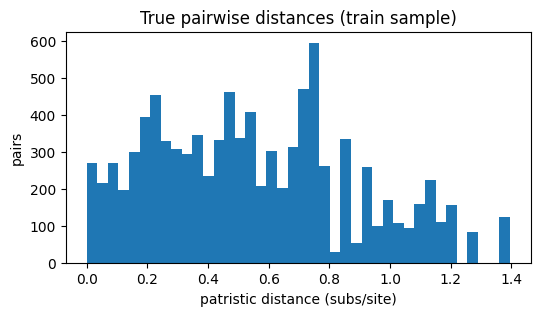

n pairs: 9500


In [9]:
#@title Data stats + distance histogram
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import dendropy

if os.path.exists(train_parquet):
    for split in ("train", "val", "test"):
        p = os.path.join(os.environ["DATA_DIR"], f"{split}.parquet")
        if os.path.exists(p):
            t = pq.read_table(p)
            tips = t["n_tips"].to_numpy()
            lens = np.array([len(s) for row in t["seqs"].to_pylist()[:200] for s in row])
            print(f"{split}: {len(t)} rows | n_tips {int(tips.min())}-{int(tips.max())} | median seq len {int(np.median(lens))}")
    t = pq.read_table(train_parquet, columns=["tree_newick"])
    dists = []
    for nwk in t["tree_newick"].to_pylist()[:50]:
        tree = dendropy.Tree.get(data=nwk, schema="newick")
        ndm = tree.node_distance_matrix()
        leaves = tree.leaf_nodes()
        for i in range(len(leaves)):
            for j in range(i + 1, len(leaves)):
                dists.append(float(ndm(leaves[i], leaves[j])))
    plt.figure(figsize=(6, 3))
    plt.hist(dists, bins=40)
    plt.xlabel("patristic distance (subs/site)")
    plt.ylabel("pairs")
    plt.title("True pairwise distances (train sample)")
    plt.show()
    print("n pairs:", len(dists))
else:
    print("no train.parquet — run the simulate cell first")


---
## Section 3 — Train
Runs `ssm_phylo.train` with `--resume latest` (session death is safe: rerunning this cell resumes from the latest checkpoint instead of restarting — pull-train-push handles Drive sync).

> **WARNING: Colab sessions can die at any moment.** Training is checkpoint-resumable: if the session dies, re-run this cell — it pulls the Drive mirror and continues from the last saved step (never double-counts steps).


In [10]:
#@title Training configuration
# run_mode: validate = fast end-to-end check (real 100M model, 2 epochs;
#           minutes even on eager Mamba). full = the real 20-epoch schedule —
#           WITHOUT kernels this can take ~1.7 days. For full-speed training,
#           ensure `kernels` is installed (Section 1 cell); otherwise the
#           full schedule is slow.
run_mode = "validate"  #@param ["validate", "full"]
# train_small = T4 smoke (fp16, 8k streams); train_l4 = Colab Pro L4-24GB
#              (bf16, 32k streams); train_a100 = A100-40GB (bf16, 64k streams).
#              Ignored in validate mode (configs/validate.yaml is used instead).
config = "train_a100"  #@param ["train_small", "train_l4", "train_a100"]
print("detected GPU:", _gpu_name or "none", "| run_mode:", run_mode, "| config picker:", config)
if DRIVE_SKIP:
    # Headless/CI: train the tiny toy model instead of the full config (fast, CPU-safe).
    toy_scratch = os.path.join(os.environ["LOCAL_DATA_DIR"], "toy_scratch")
    pathlib.Path(toy_scratch).mkdir(parents=True, exist_ok=True)
    cmd = [sys.executable, "-m", "ssm_phylo.train", "--toy",
           "--data-dir", toy_scratch, "--resume", "latest"]
    print("headless mode: training the TOY model (CI-fast) —", " ".join(cmd))
else:
    if run_mode == "validate":
        config_file = f"{REPO_DIR}/configs/validate.yaml"
        runtime_note = "VALIDATION MODE \u2014 minutes even on eager Mamba"
    else:
        config_file = f"{REPO_DIR}/configs/{config}.yaml"
        runtime_note = ("FULL schedule \u2014 WITHOUT kernels this can take ~1.7 days; "
                         "ensure `kernels` is installed (Section 1 cell)")
    cmd = [sys.executable, "-m", "ssm_phylo.train",
           "--config", config_file,
           "--resume", "latest",
           "--data-dir", os.environ["DATA_DIR"],
           "--ckpt-dir", os.environ["CKPT_DIR"]]
    if os.environ.get("RESULTS_DIR"):
        cmd += ["--results-dir", os.environ["RESULTS_DIR"]]
    extra = os.environ.get("SSM_PHYLO_NOTEBOOK_TRAIN_EXTRA", "")
    cmd += extra.split()
    print(" ".join(cmd))
    print(runtime_note)


detected GPU: NVIDIA A100-SXM4-40GB | run_mode: validate | config picker: train_a100
/usr/bin/python3 -m ssm_phylo.train --config /content/ssm-phylo/configs/validate.yaml --resume latest --data-dir /content/drive/MyDrive/ssm-phylo/data --ckpt-dir /content/drive/MyDrive/ssm-phylo/checkpoints --results-dir /content/drive/MyDrive/ssm-phylo/results
VALIDATION MODE — minutes even on eager Mamba


In [11]:
#@title Train (streaming output; re-run to RESUME, not restart)
proc = subprocess.Popen(cmd, env=os.environ, cwd=REPO_DIR, text=True,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="")
rc = proc.wait()
print("\ntrain exit:", rc)


[15:41:53] INFO ssm_phylo.train: device=cuda precision=bf16 (scaler=False)
[15:41:58] INFO numexpr.utils: NumExpr defaulting to 12 threads.
[transformers] The fast path is not available because one of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. Falling back to the mamba.py backend. To install follow https://github.com/state-spaces/mamba/#installation for mamba-ssm and install the kernels library using `pip install kernels` or https://github.com/Dao-AILab/causal-conv1d for causal-conv1d
[15:42:00] INFO ssm_phylo.models.encoder: encoder: MambaForCausalLM MambaConfig {
  "bos_token_id": 0,
  "conv_kernel": 4,
  "eos_token_id": 0,
  "expand": 2,
  "hidden_act": "silu",
  "hidden_size": 1024,
  "initializer_range": 0.1,
  "intermediate_size": 2048,
  "layer_norm_epsilon": 1e-05,
  "model_type": "mamba",
  "num_hidden_layers": 16,
  "pad_token_id": 0,
  "rescale_prenorm_residual": false,
  "residual_in_fp32": true,
  "state_s

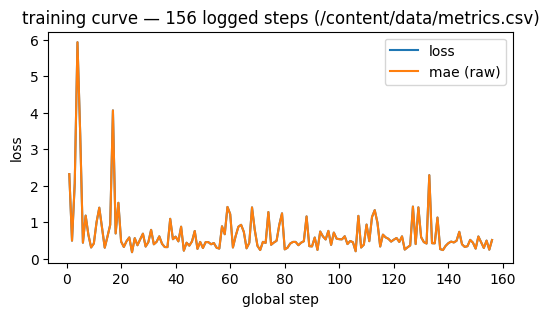

In [12]:
#@title Loss curve from metrics.csv
import csv

# Fresh-VM resume safety: pull the Drive mirror first so latest.pt/metrics
# reflect the last session (no-op headless).
if not DRIVE_SKIP and os.environ.get("CKPT_DIR") and os.environ.get("LOCAL_CKPT_DIR"):
    subprocess.run(["bash", f"{REPO_DIR}/scripts/sync_drive.sh", "pull"], env=os.environ, check=False)
candidates = [
    os.path.join(os.environ["LOCAL_DATA_DIR"], "metrics.csv"),
    os.path.join(os.environ["LOCAL_DATA_DIR"], "toy_scratch", "metrics.csv"),
]
csv_path = next((p for p in candidates if os.path.exists(p)), None)
if csv_path is None:
    print("no metrics.csv found — train at least once")
else:
    rows = [r for r in csv.DictReader(open(csv_path)) if r.get("loss")]
    steps = [int(r["step"]) for r in rows]
    plt.figure(figsize=(6, 3))
    plt.plot(steps, [float(r["loss"]) for r in rows], label="loss")
    plt.plot(steps, [float(r["mae"]) for r in rows], label="mae (raw)")
    plt.xlabel("global step"); plt.ylabel("loss")
    plt.legend(); plt.title(f"training curve — {len(rows)} logged steps ({csv_path})")
    plt.show()


---
## Section 4 — Evaluate
Runs `colab_eval.sh` (pull + evaluate latest checkpoint on `$DATA_DIR/test.parquet`), renders `results.csv` as a markdown table, and plots RF vs n_tips / RF vs seq_len (figures saved to `$RESULTS_DIR`). Skipped when `results.csv` already exists (unless **re-run** is checked).


In [17]:
#@title Evaluate (skip if results.csv exists)
rerun_eval = True  #@param {type:"boolean"}
out_dir = os.path.join(os.environ["RESULTS_DIR"], "eval_v1")
results_csv = os.path.join(out_dir, "results.csv")
if os.path.exists(results_csv) and not rerun_eval:
    print(f"results.csv exists — skipping evaluation (check 're-run' to redo): {results_csv}")
else:
    if DRIVE_SKIP:
        import glob
        ckpts = sorted(glob.glob(os.path.join(os.environ["LOCAL_CKPT_DIR"], "*.pt")))
        if not ckpts:
            raise SystemExit("no checkpoints found — run Section 3 first")
        eval_cmd = [sys.executable, "-m", "ssm_phylo.evaluate",
                    "--checkpoint", ckpts[-1],
                    "--test-parquet", os.path.join(os.environ["DATA_DIR"], "test.parquet"),
                    "--out-dir", out_dir,
                    "--max-alignments", "100"]
        proc = subprocess.run(eval_cmd, env=os.environ, cwd=REPO_DIR, text=True)
    else:
        env = {**os.environ, "SSM_PHYLO_EVAL_EXTRA": "--max-alignments 200"}
        proc = subprocess.run(["bash", f"{REPO_DIR}/scripts/colab_eval.sh"],
                             env=env, cwd=REPO_DIR, text=True)
    print("\nevaluate exit:", proc.returncode)



evaluate exit: 0


In [18]:
#@title results.csv as markdown
if os.path.exists(results_csv):
    rows = list(csv.DictReader(open(results_csv)))
    print(f"| {' | '.join(rows[0].keys())} |")
    print(f"|{'---|' * len(rows[0])}")
    for r in rows[:20]:
        print(f"| {' | '.join(r.values())} |")
    print(f"... {len(rows)} rows total")
else:
    print(f"no results.csv at {results_csv} — run the evaluate cell first")


| index | n_tips | seq_len | rf_pred | rf_true_dist_upper_bound | elapsed_s |
|---|---|---|---|---|---|
| 16 | 20 | 150.0 | 1.0 | 0.0 | 4.528 |
| 0 | 20 | 150.0 | 1.0 | 0.0 | 3.932 |
| 3 | 20 | 150.0 | 1.0 | 0.0 | 3.877 |
| 1 | 20 | 150.0 | 1.0 | 0.0 | 4.042 |
| 14 | 20 | 150.0 | 1.0 | 0.0 | 3.884 |
| 11 | 20 | 150.0 | 1.0 | 0.0 | 3.856 |
| 10 | 20 | 150.0 | 1.0 | 0.0 | 4.025 |
| 5 | 20 | 150.0 | 0.9412 | 0.0 | 3.883 |
| 7 | 20 | 150.0 | 1.0 | 0.0 | 3.867 |
| 9 | 20 | 150.0 | 1.0 | 0.0 | 3.852 |
| 15 | 20 | 150.0 | 1.0 | 0.0 | 4.041 |
| 4 | 20 | 150.0 | 1.0 | 0.0 | 3.85 |
| 13 | 20 | 150.0 | 1.0 | 0.0 | 3.846 |
| 6 | 20 | 150.0 | 1.0 | 0.0 | 4.021 |
| 12 | 20 | 150.0 | 1.0 | 0.0 | 3.853 |
| 2 | 20 | 150.0 | 1.0 | 0.0 | 3.869 |
| 8 | 20 | 150.0 | 1.0 | 0.0 | 3.83 |
... 17 rows total


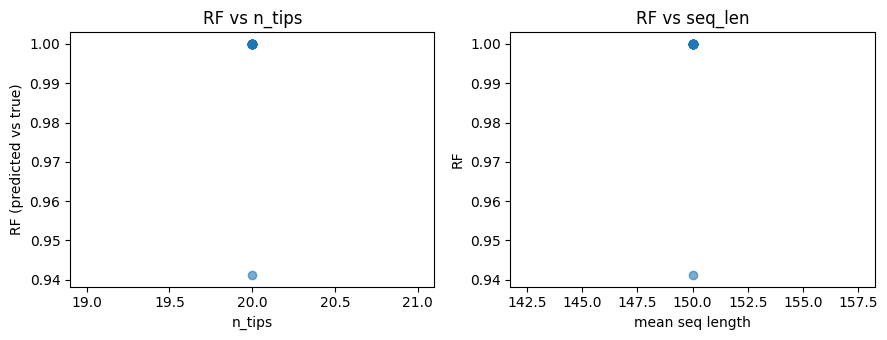

saved: /content/drive/MyDrive/ssm-phylo/results/eval_v1/rf_plots.png


In [19]:
#@title RF vs n_tips and RF vs seq_len (saved to $RESULTS_DIR)
if os.path.exists(results_csv):
    rows = list(csv.DictReader(open(results_csv)))
    x1 = [int(r["n_tips"]) for r in rows]
    y = [float(r["rf_pred"]) for r in rows]
    x2 = [float(r["seq_len"]) for r in rows]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
    ax1.scatter(x1, y, alpha=0.6)
    ax1.set_xlabel("n_tips"); ax1.set_ylabel("RF (predicted vs true)")
    ax1.set_title("RF vs n_tips")
    ax2.scatter(x2, y, alpha=0.6)
    ax2.set_xlabel("mean seq length"); ax2.set_ylabel("RF")
    ax2.set_title("RF vs seq_len")
    plt.tight_layout()
    fig_path = os.path.join(out_dir, "rf_plots.png")
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("saved:", fig_path)
else:
    print("no results.csv yet — run the evaluate cell first")
